# Qwen3-4B SFT + GRPO Training Notebook
This notebook prepares SFT data, runs SFT training, then performs GRPO-based RL post-training from the SFT checkpoint. It saves plots inline and as PNG files.

In [1]:
import sys
from pathlib import Path
CWD = Path.cwd()
ROOT = CWD.parent if CWD.name == 'notebooks' else CWD
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print('repo_root', ROOT)

repo_root /local/mnt/workspace/ddudhat/finals


In [2]:
import sys
print(sys.executable)

/root/.cache/uv/builds-v0/.tmpVgrycx/bin/python


In [3]:
# Install / verify packages
packages = [
    "torch>=2.9.0",
    "transformers>=5.6.0",
    "datasets>=4.8.0",
    "trl==1.2.0",
    "peft>=0.19.0",
    "accelerate>=1.13.0",
    "matplotlib>=3.8.0",
    "jupyter>=1.1.0",
    "nbconvert>=7.16.0",
    "nbformat>=5.10.0",
]
print("Install with:")
print("uv pip install --python .venv/bin/python " + " ".join(repr(p) for p in packages))

Install with:
uv pip install --python .venv/bin/python 'torch>=2.9.0' 'transformers>=5.6.0' 'datasets>=4.8.0' 'trl==1.2.0' 'peft>=0.19.0' 'accelerate>=1.13.0' 'matplotlib>=3.8.0' 'jupyter>=1.1.0' 'nbconvert>=7.16.0' 'nbformat>=5.10.0'


In [4]:
import json
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset
from peft import LoraConfig
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments
from trl import SFTTrainer
print("torch", torch.__version__, "cuda", torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

torch 2.8.0+cu128 cuda True
NVIDIA A100-SXM4-80GB


In [5]:
import json
from pathlib import Path

CWD = Path.cwd()
ROOT = CWD.parent if CWD.name == 'notebooks' else CWD
EPISODES_DIR = ROOT / "data" / "tasks" / "robust_episodes"
GROUND_TRUTH = json.loads((ROOT / "data" / "jira_outlook_robust_case.json").read_text())
OUT_PATH = ROOT / "data" / "training" / "sft_train.jsonl"
SYSTEM_PROMPT = (
    "You are a careful ticket triage agent working in a constrained tool-use environment. "
    "Use only the provided Jira and Outlook tools. Return exactly one JSON action."
)
GT_BY_ID = {r["ticket_number"]: r for r in GROUND_TRUTH["jira_records"]}
KEY_PHRASES = [
    "IllegalStateException", "NotificationPreferenceAssembler", "empty locale map", "profile hydration",
    "duplicate redemption", "ledger_event_id", "certificate thumbprint", "invoice footer",
    "template revision", "sample output", "acknowledgement template", "renderer fallback",
    "locale fallback", "tax rounding mismatch", "currency switch", "digest notifications", "timezone migration",
]

def query_variants(logs):
    matched = [phrase for phrase in KEY_PHRASES if phrase.lower() in logs.lower()]
    variants = []
    if matched:
        variants.append(' '.join(matched[:4]))
        variants.append(' '.join(matched[:2]))
    words = logs.split()
    variants.append(' '.join(words[:12]))
    variants.append(' '.join(words[12:24]))
    deduped = []
    for item in variants:
        item = ' '.join(item.split())
        if item and item not in deduped:
            deduped.append(item)
    return deduped

def msg_example(obs, action):
    return {
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": json.dumps(obs, indent=2)},
            {"role": "assistant", "content": json.dumps(action, ensure_ascii=False)},
        ]
    }

examples = []
for path in sorted(EPISODES_DIR.glob('*.json')):
    task = json.loads(path.read_text())
    ticket = task['assigned_ticket_number']
    gt = GT_BY_ID[ticket]
    assigned = next(r for r in task['jira_records'] if r['ticket_number'] == ticket)
    obs0 = {
        'task_id': task['task_id'],
        'assigned_ticket_number': ticket,
        'objective': task['objective'],
        'steps_taken': 0,
        'assigned_ticket': assigned,
        'history': [],
    }
    path_nodes = gt.get('ground_truth_path', [])
    resolution = gt.get('resolution')
    resolution_notes = gt.get('resolution_notes')
    searches = query_variants(gt['logs'])
    if resolution == 'duplicate' and path_nodes:
        canonical = path_nodes[-1]
        for q in searches[:2]:
            examples.append(msg_example(obs0, {'tool': 'search_jira', 'query': q}))
        hist = [{'action': {'tool': 'search_jira', 'query': searches[0]}, 'result_hint': f'Finds canonical or bridge evidence for {ticket}'}]
        obs1 = {**obs0, 'steps_taken': 1, 'history': hist}
        examples.append(msg_example(obs1, {'tool': 'get_jira_ticket', 'ticket_number': canonical}))
        obs2 = {**obs0, 'steps_taken': 2, 'history': hist + [{'action': {'tool': 'get_jira_ticket', 'ticket_number': canonical}, 'result_hint': f'Reveals closed canonical Jira {canonical}'}]}
        examples.append(msg_example(obs2, {'tool': 'submit_resolution', 'ticket_number': ticket, 'resolution': 'duplicate', 'resolution_notes': resolution_notes}))
    elif resolution == 'needs_more_info':
        for q in searches[:2]:
            examples.append(msg_example(obs0, {'tool': 'search_outlook', 'query': q}))
        hist = [{'action': {'tool': 'search_outlook', 'query': searches[0]}, 'result_hint': f'Finds missing-information thread for {ticket}'}]
        obs1 = {**obs0, 'steps_taken': 1, 'history': hist}
        examples.append(msg_example(obs1, {'tool': 'submit_resolution', 'ticket_number': ticket, 'resolution': 'needs_more_info'}))
    else:
        for q in searches[:3]:
            examples.append(msg_example(obs0, {'tool': 'search_jira', 'query': q}))

OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
OUT_PATH.write_text(''.join(json.dumps(item) + "\n" for item in examples))
print(f'wrote {len(examples)} examples to {OUT_PATH}')

wrote 75 examples to /local/mnt/workspace/ddudhat/finals/data/training/sft_train.jsonl


In [6]:
dataset = load_dataset("json", data_files=str(ROOT / "data" / "training" / "sft_train.jsonl"), split="train")
print(dataset)
print(dataset[0])

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['messages'],
    num_rows: 75
})
{'messages': [{'role': 'system', 'content': 'You are a careful ticket triage agent working in a constrained tool-use environment. Use only the provided Jira and Outlook tools. Return exactly one JSON action.'}, {'role': 'user', 'content': '{\n  "task_id": "robust_jira_2090",\n  "assigned_ticket_number": "JIRA-2090",\n  "objective": "Investigate the assigned Jira ticket and submit the correct resolution using Jira and Outlook evidence.",\n  "steps_taken": 0,\n  "assigned_ticket": {\n    "ticket_number": "JIRA-2090",\n    "assignee": "deepa.nair",\n    "logs": "Build 2026.05.6 checkout service showed intermittent tax rounding mismatch when cart currency switched from JPY to USD mid-session. Logs mention stale currency context and cache carryover from previous quote computation. Support saw the mismatch only after account locale changed and cart totals were recalculated from an old quote snapshot.",\n    "date": "2026-05-13",\n    

In [7]:
def format_example(example):
    parts = []
    for msg in example["messages"]:
        parts.append(f"<|im_start|>{msg['role']}\n{msg['content']}<|im_end|>")
    return {"text": "\n".join(parts)}

formatted = dataset.map(format_example)
print(formatted[0]["text"][:800])

Map:   0%|          | 0/75 [00:00<?, ? examples/s]

<|im_start|>system
You are a careful ticket triage agent working in a constrained tool-use environment. Use only the provided Jira and Outlook tools. Return exactly one JSON action.<|im_end|>
<|im_start|>user
{
  "task_id": "robust_jira_2090",
  "assigned_ticket_number": "JIRA-2090",
  "objective": "Investigate the assigned Jira ticket and submit the correct resolution using Jira and Outlook evidence.",
  "steps_taken": 0,
  "assigned_ticket": {
    "ticket_number": "JIRA-2090",
    "assignee": "deepa.nair",
    "logs": "Build 2026.05.6 checkout service showed intermittent tax rounding mismatch when cart currency switched from JPY to USD mid-session. Logs mention stale currency context and cache carryover from previous quote computation. Support saw the mismatch only after account locale c


In [8]:
MODEL_NAME = "Qwen/Qwen3-4B-Instruct-2507"
OUTPUT_DIR = "training/output/qwen3_4b_sft_notebook"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype="auto",
    device_map="auto",
)

peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "up_proj", "down_proj", "gate_proj"],
)

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3.0,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=16,
    learning_rate=2e-4,
    logging_steps=1,
    save_steps=100,
    bf16=torch.cuda.is_available(),
    report_to="none",
    remove_unused_columns=False,
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=formatted,
    processing_class=tokenizer,
    peft_config=peft_config,
    formatting_func=lambda ex: ex["text"],
)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Applying formatting function to train dataset:   0%|          | 0/75 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/75 [00:00<?, ? examples/s]

In [9]:
train_result = trainer.train()
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(train_result)

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
1,3.151918
2,2.709101
3,2.242957
4,2.188240
5,1.948023
6,1.781064
7,1.560838
8,1.447599
9,1.347059
10,1.263154


TrainOutput(global_step=15, training_loss=1.6730738004048666, metrics={'train_runtime': 95.5501, 'train_samples_per_second': 2.355, 'train_steps_per_second': 0.157, 'total_flos': 1652253857510400.0, 'train_loss': 1.6730738004048666})


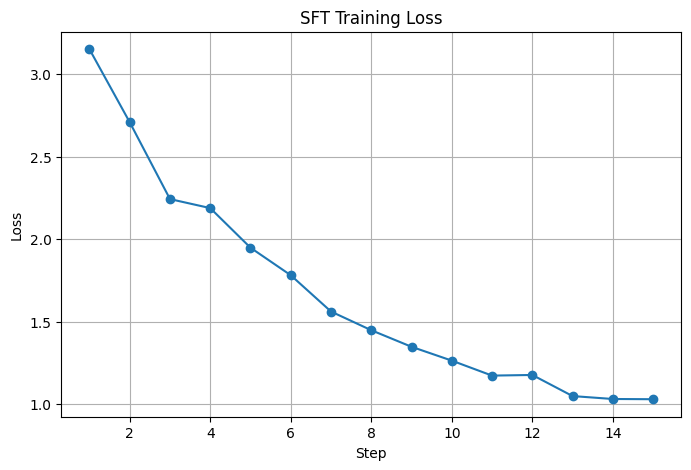

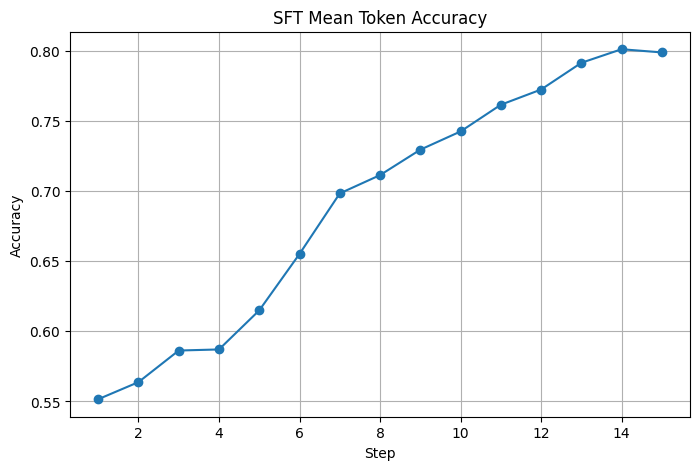

Saved: /local/mnt/workspace/ddudhat/finals/training/plots/sft_loss_curve.png
Saved: /local/mnt/workspace/ddudhat/finals/training/plots/sft_accuracy_curve.png


In [10]:
from pathlib import Path
output_root = Path(OUTPUT_DIR)
state_candidates = sorted(output_root.glob("checkpoint-*/trainer_state.json"))
state_path = state_candidates[-1] if state_candidates else output_root / "trainer_state.json"
state = json.loads(state_path.read_text())
logs = [entry for entry in state["log_history"] if "loss" in entry]
steps = [entry["step"] for entry in logs]
losses = [entry["loss"] for entry in logs]
accs = [entry.get("mean_token_accuracy") for entry in logs]

plot_dir = ROOT / "training" / "plots"
plot_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8,5))
plt.plot(steps, losses, marker="o")
plt.title("SFT Training Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.grid(True)
loss_png = plot_dir / "sft_loss_curve.png"
plt.savefig(loss_png, dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(steps, accs, marker="o")
plt.title("SFT Mean Token Accuracy")
plt.xlabel("Step")
plt.ylabel("Accuracy")
plt.grid(True)
acc_png = plot_dir / "sft_accuracy_curve.png"
plt.savefig(acc_png, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", loss_png)
print("Saved:", acc_png)

In [11]:
from peft import PeftModel
base = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype="auto", device_map="auto")
model = PeftModel.from_pretrained(base, OUTPUT_DIR)
prompt = """<|im_start|>system
You are a careful ticket triage agent working in a constrained tool-use environment. Use only the provided Jira and Outlook tools. Return exactly one JSON action.<|im_end|>
<|im_start|>user
{"task_id":"robust_jira_2104","assigned_ticket_number":"JIRA-2104","objective":"Investigate the assigned Jira ticket and submit the correct resolution using Jira and Outlook evidence.","steps_taken":0,"assigned_ticket":{"ticket_number":"JIRA-2104","assignee":"nisha.patel","logs":"Build 2026.05.7 failed during post-deploy validation in the notification preference sync flow. Service logs show IllegalStateException when NotificationPreferenceAssembler processes an empty locale map after profile hydration retry.","date":"2026-05-18","build_number":"2026.05.7","resolution":"unresolved","status":"open","resolution_notes":null},"history":[]}<|im_end|>
<|im_start|>assistant
"""
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
out = model.generate(**inputs, max_new_tokens=80, do_sample=False)
print(tokenizer.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True))

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


{"tool": "search_jira", "query": "notification preference sync"}


## GRPO Post-Training
This section loads the SFT adapter and performs GRPO-based post-training with environment-derived rewards. It also saves reward and loss plots to disk while displaying them inline.

In [12]:
import json
from pathlib import Path

from peft import LoraConfig, PeftModel
from trl import GRPOConfig, GRPOTrainer

GRPO_OUTPUT_DIR = ROOT / "training" / "output" / "qwen3_4b_grpo_notebook"
GRPO_PLOT_DIR = ROOT / "training" / "plots"
GRPO_PLOT_DIR.mkdir(parents=True, exist_ok=True)
GRPO_EPISODES = 12
GRPO_MAX_PROMPT_CHARS = 6000


In [13]:
grpo_source = load_dataset("json", data_files=str(ROOT / "data" / "training" / "sft_train.jsonl"), split="train")

def to_grpo_prompt(example):
    user_msg = next(msg["content"] for msg in example["messages"] if msg["role"] == "user")
    assistant_msg = next(msg["content"] for msg in example["messages"] if msg["role"] == "assistant")
    prompt = f"<|im_start|>system\n{SYSTEM_PROMPT}<|im_end|>\n<|im_start|>user\n{user_msg}<|im_end|>\n<|im_start|>assistant\n"
    return {
        "prompt": prompt[:GRPO_MAX_PROMPT_CHARS],
        "reference_action": assistant_msg,
    }

grpo_dataset = grpo_source.map(to_grpo_prompt, remove_columns=grpo_source.column_names)
print(grpo_dataset)
print(grpo_dataset[0])

Map:   0%|          | 0/75 [00:00<?, ? examples/s]

Dataset({
    features: ['prompt', 'reference_action'],
    num_rows: 75
})
{'prompt': '<|im_start|>system\nYou are a careful ticket triage agent working in a constrained tool-use environment. Use only the provided Jira and Outlook tools. Return exactly one JSON action.<|im_end|>\n<|im_start|>user\n{\n  "task_id": "robust_jira_2090",\n  "assigned_ticket_number": "JIRA-2090",\n  "objective": "Investigate the assigned Jira ticket and submit the correct resolution using Jira and Outlook evidence.",\n  "steps_taken": 0,\n  "assigned_ticket": {\n    "ticket_number": "JIRA-2090",\n    "assignee": "deepa.nair",\n    "logs": "Build 2026.05.6 checkout service showed intermittent tax rounding mismatch when cart currency switched from JPY to USD mid-session. Logs mention stale currency context and cache carryover from previous quote computation. Support saw the mismatch only after account locale changed and cart totals were recalculated from an old quote snapshot.",\n    "date": "2026-05-13",\n  

In [14]:
grpo_reward_history = []

def parse_json_action(text):
    start = text.find("{")
    end = text.rfind("}")
    if start == -1 or end == -1:
        return None
    try:
        return json.loads(text[start:end + 1])
    except Exception:
        return None

def structural_reward(completions, reference_action, **kwargs):
    rewards = []
    for completion, reference in zip(completions, reference_action):
        payload = parse_json_action(completion)
        ref_payload = parse_json_action(reference)
        reward = -0.2
        if payload is not None:
            reward = 0.1
            if ref_payload is not None and payload.get("tool") == ref_payload.get("tool"):
                reward += 0.35
            if ref_payload is not None and payload.get("resolution") == ref_payload.get("resolution"):
                reward += 0.35
            if ref_payload is not None and payload.get("resolution_notes") == ref_payload.get("resolution_notes"):
                reward += 0.2
        grpo_reward_history.append(float(reward))
        rewards.append(float(reward))
    return rewards

def extract_grpo_losses(log_history):
    losses = []
    for entry in log_history:
        if isinstance(entry, dict):
            if "loss" in entry:
                losses.append(float(entry["loss"]))
            elif "train_loss" in entry:
                losses.append(float(entry["train_loss"]))
    return losses


In [15]:
grpo_reward_history = []

grpo_config = GRPOConfig(
    output_dir=str(GRPO_OUTPUT_DIR),
    learning_rate=5e-6,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    num_generations=4,
    max_completion_length=128,
    logging_steps=1,
    num_train_epochs=2,
    save_steps=3,
    report_to="none",
    bf16=torch.cuda.is_available(),
)

base_for_grpo = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype="auto", device_map="auto")
sft_loaded = PeftModel.from_pretrained(base_for_grpo, str(OUTPUT_DIR))
merged_for_grpo = sft_loaded.merge_and_unload()

grpo_peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "up_proj", "down_proj", "gate_proj"],
)

grpo_tokenizer = AutoTokenizer.from_pretrained(str(OUTPUT_DIR), use_fast=True)
if grpo_tokenizer.pad_token is None:
    grpo_tokenizer.pad_token = grpo_tokenizer.eos_token

grpo_trainer = GRPOTrainer(
    model=merged_for_grpo,
    reward_funcs=structural_reward,
    args=grpo_config,
    train_dataset=grpo_dataset.select(range(min(GRPO_EPISODES, len(grpo_dataset)))),
    processing_class=grpo_tokenizer,
    peft_config=grpo_peft_config,
)

grpo_train_result = grpo_trainer.train()
grpo_trainer.save_model(str(GRPO_OUTPUT_DIR))
print(grpo_train_result)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
1,0.089423
2,0.272450
3,-0.010632
4,0.000000
5,-0.060941
6,0.854296
7,0.000000
8,0.166627
9,-0.083230
10,0.118321


TrainOutput(global_step=24, training_loss=0.109464131295681, metrics={'train_runtime': 259.8696, 'train_samples_per_second': 0.092, 'train_steps_per_second': 0.092, 'total_flos': 0.0, 'train_loss': 0.109464131295681})


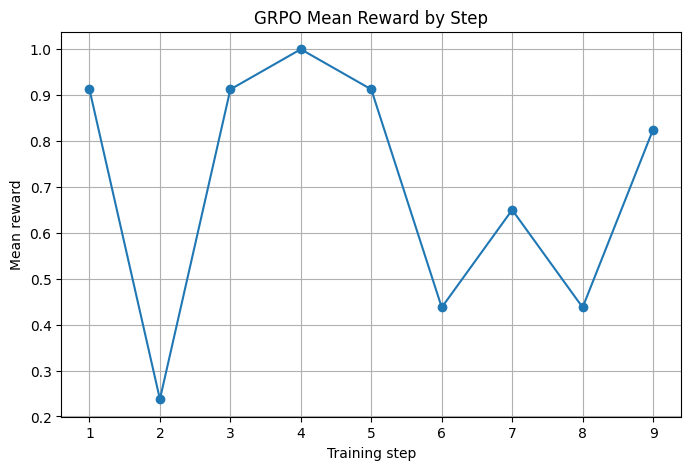

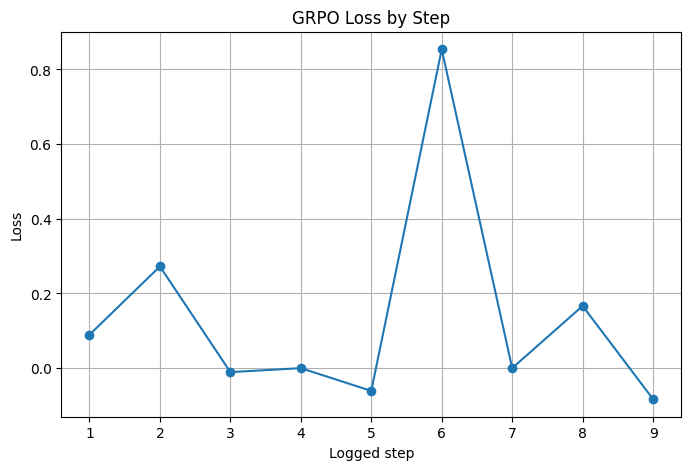

Saved: /local/mnt/workspace/ddudhat/finals/training/plots/grpo_reward_curve.png
Saved: /local/mnt/workspace/ddudhat/finals/training/plots/grpo_loss_curve.png
reward_points 9
loss_points 9
latest_reward 0.824999988079071
latest_loss -0.08323046565055847


In [16]:
checkpoint_states = sorted((GRPO_OUTPUT_DIR).glob("checkpoint-*/trainer_state.json"))
trainer_state_path = checkpoint_states[-1] if checkpoint_states else GRPO_OUTPUT_DIR / "trainer_state.json"
trainer_state = json.loads(trainer_state_path.read_text()) if trainer_state_path.exists() else {"log_history": []}
log_history = trainer_state.get("log_history", [])
grop_losses = extract_grpo_losses(log_history)
reward_means = [float(entry["reward"]) for entry in log_history if isinstance(entry, dict) and "reward" in entry]
steps = [int(entry["step"]) for entry in log_history if isinstance(entry, dict) and "step" in entry and "reward" in entry]
reward_png = GRPO_PLOT_DIR / "grpo_reward_curve.png"
loss_png = GRPO_PLOT_DIR / "grpo_loss_curve.png"

plt.figure(figsize=(8, 5))
plt.plot(steps if steps else range(1, len(reward_means) + 1), reward_means, marker="o")
plt.title("GRPO Mean Reward by Step")
plt.xlabel("Training step")
plt.ylabel("Mean reward")
plt.grid(True)
plt.savefig(reward_png, dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(grop_losses) + 1), grop_losses, marker="o")
plt.title("GRPO Loss by Step")
plt.xlabel("Logged step")
plt.ylabel("Loss")
plt.grid(True)
plt.savefig(loss_png, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", reward_png)
print("Saved:", loss_png)
print("reward_points", len(reward_means))
print("loss_points", len(grop_losses))
print("latest_reward", reward_means[-1] if reward_means else None)
print("latest_loss", grop_losses[-1] if grop_losses else None)